In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
data=pd.read_csv("winequalityN.csv")
data


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
data.shape

(6497, 13)

In [4]:
data.describe

<bound method NDFrame.describe of        type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0     white            7.0             0.270         0.36            20.7   
1     white            6.3             0.300         0.34             1.6   
2     white            8.1             0.280         0.40             6.9   
3     white            7.2             0.230         0.32             8.5   
4     white            7.2             0.230         0.32             8.5   
...     ...            ...               ...          ...             ...   
6492    red            6.2             0.600         0.08             2.0   
6493    red            5.9             0.550         0.10             2.2   
6494    red            6.3             0.510         0.13             2.3   
6495    red            5.9             0.645         0.12             2.0   
6496    red            6.0             0.310         0.47             3.6   

      chlorides  free sulfur dioxide  tot

In [5]:
data.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [6]:
data['fixed acidity']=data['fixed acidity'].fillna(data['fixed acidity'].mean())
data['volatile acidity']=data['volatile acidity'].fillna(data['volatile acidity'].mean())
data['citric acid']=data['citric acid'].fillna(data['citric acid'].mean())
data['residual sugar']=data['residual sugar'].fillna(data['residual sugar'].mean())
data['chlorides']=data['chlorides'].fillna(data['chlorides'].mean())
data['pH']=data['pH'].fillna(data['pH'].mean())
data['sulphates']=data['sulphates'].fillna(data['sulphates'].mean())
data.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

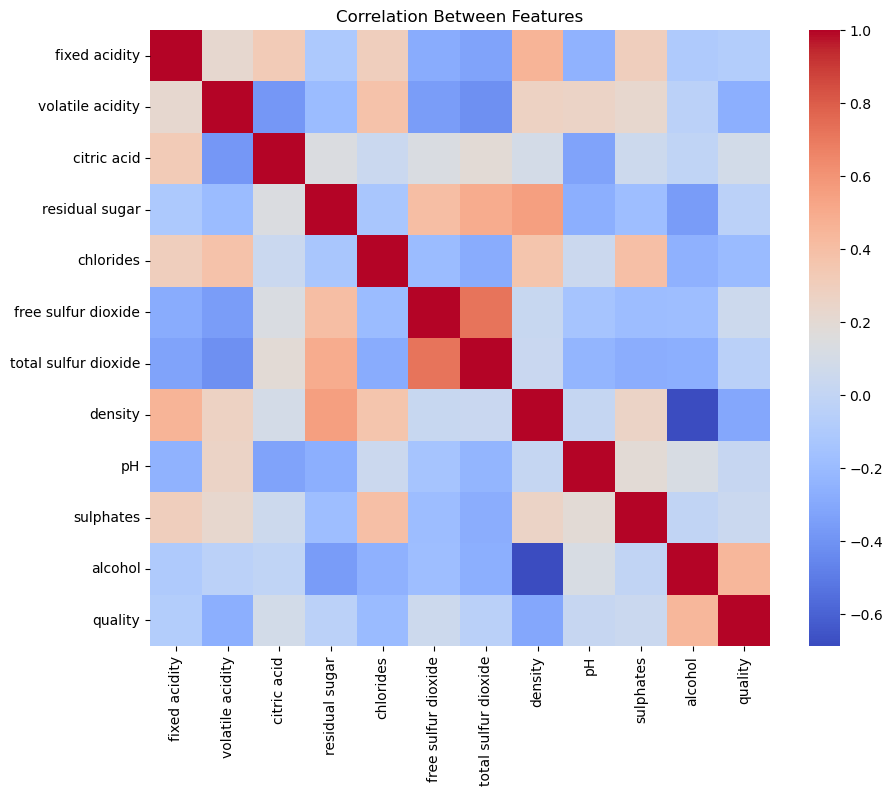

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm")
plt.title('Correlation Between Features')
plt.show()

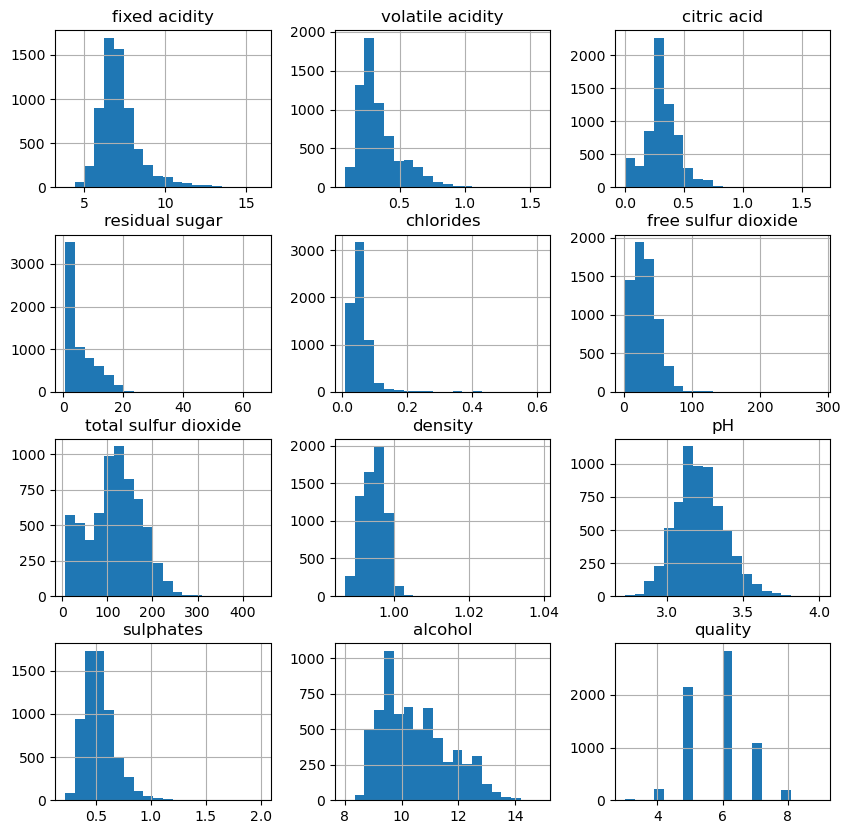

In [8]:
data.hist(bins=20, figsize=(10, 10))
plt.show()

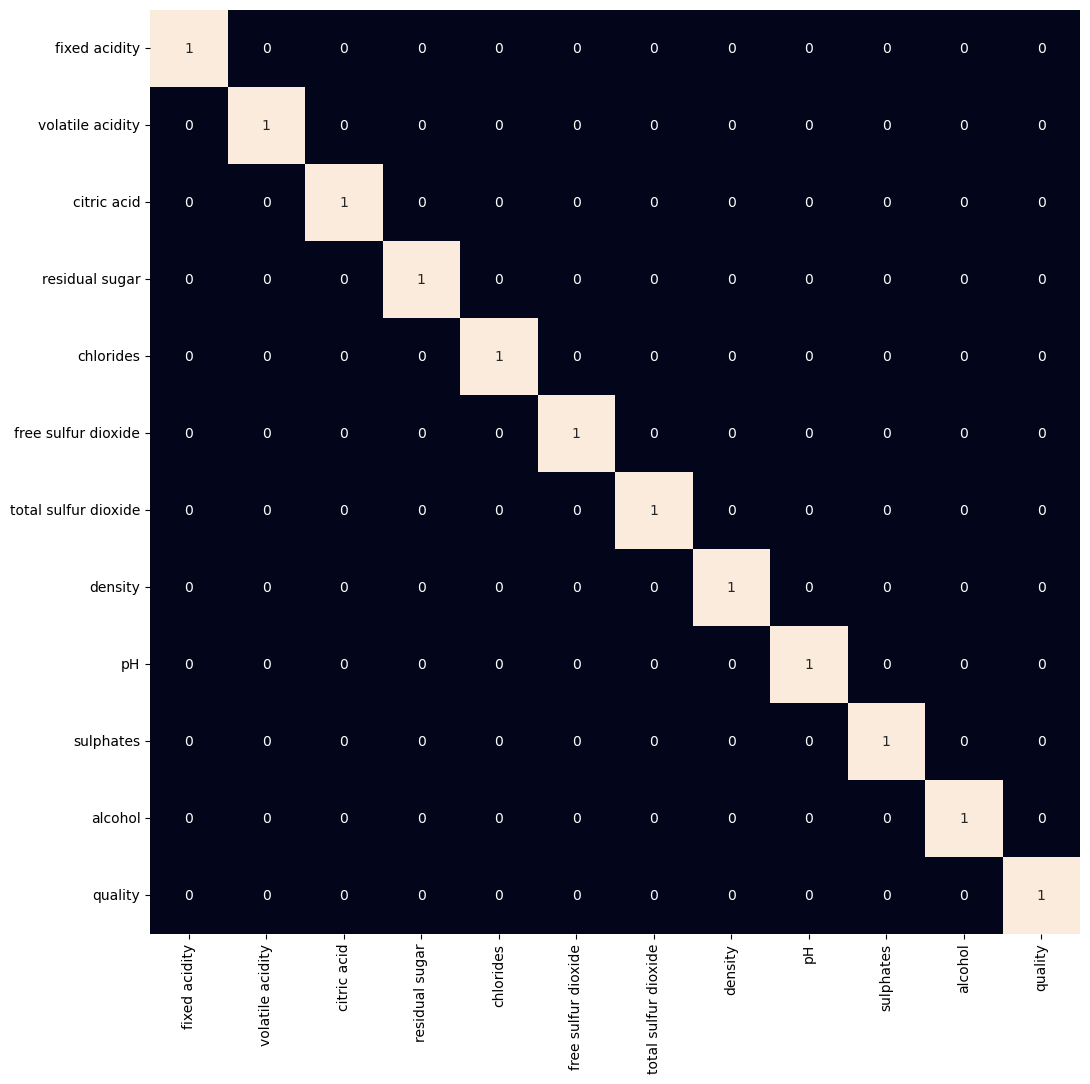

In [9]:
plt.figure(figsize=(12,12))
sns.heatmap(data.corr(numeric_only=True)>0.8, annot=True, cbar=False)
plt.show()

In [10]:
data['best quality'] = [1 if x > 5 else 0 for x in data.quality]
data.replace({'white':1, 'red':0}, inplace=True)
data


C:\Users\ygvin\AppData\Local\Temp\ipykernel_25036\4252099878.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'white':1, 'red':0}, inplace=True)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,best quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.450000,8.8,6,1
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.490000,9.5,6,1
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.440000,10.1,6,1
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.400000,9.9,6,1
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.400000,9.9,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.580000,10.5,5,0
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.531215,11.2,6,1
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.750000,11.0,6,1
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.710000,10.2,5,0


In [11]:
y=data['best quality']
x=data.drop(['best quality', 'quality'],axis=1)


In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



In [13]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import preprocessing
from sklearn import metrics

In [14]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))
from sklearn.metrics import precision_recall_fscore_support as score
precision,recall,fscore,support = score(y_test,y_pred,average='macro')
LR=fscore
LR

              precision    recall  f1-score   support

           0       0.64      0.57      0.60       468
           1       0.77      0.82      0.80       832

    accuracy                           0.73      1300
   macro avg       0.71      0.70      0.70      1300
weighted avg       0.73      0.73      0.73      1300



C:\Users\ygvin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7003827199190835

In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score as ac
confusion_matrix=confusion_matrix(y_test,y_pred)
print(confusion_matrix)

[[268 200]
 [150 682]]


In [16]:
#KNN
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
%matplotlib inline
k_range = [2*i+1 for i in range(0,20)]
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn,x_train , y_train, cv = 10)
    k_scores.append(scores.mean())
    print("K value=",k)
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    print(classification_report(y_test,pred))

K value= 1
              precision    recall  f1-score   support

           0       0.65      0.67      0.66       468
           1       0.81      0.80      0.81       832

    accuracy                           0.75      1300
   macro avg       0.73      0.74      0.73      1300
weighted avg       0.75      0.75      0.75      1300

K value= 3
              precision    recall  f1-score   support

           0       0.58      0.54      0.56       468
           1       0.75      0.78      0.76       832

    accuracy                           0.69      1300
   macro avg       0.67      0.66      0.66      1300
weighted avg       0.69      0.69      0.69      1300

K value= 5
              precision    recall  f1-score   support

           0       0.56      0.51      0.53       468
           1       0.74      0.77      0.75       832

    accuracy                           0.68      1300
   macro avg       0.65      0.64      0.64      1300
weighted avg       0.67      0.68      0.

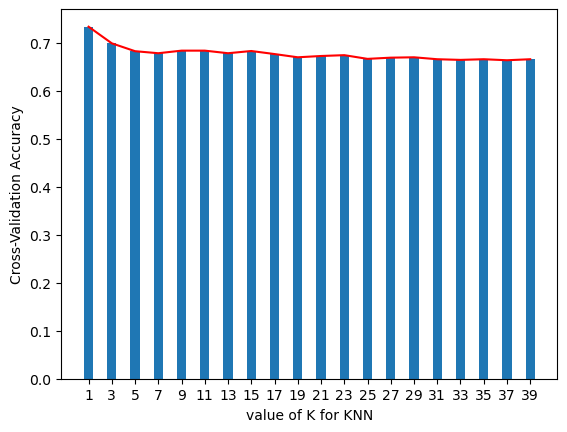

In [17]:
plt.bar(k_range, k_scores)
plt.plot(k_range, k_scores, color = "red")
    
plt.xlabel('value of K for KNN')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(k_range)
plt.show()

In [18]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)
pred = model.predict(x_test)

In [19]:
print(classification_report(y_test,pred))
precision,recall,fscore,support = score(y_test,pred,average='macro')
KNN=fscore
KNN

              precision    recall  f1-score   support

           0       0.56      0.51      0.53       468
           1       0.74      0.77      0.75       832

    accuracy                           0.68      1300
   macro avg       0.65      0.64      0.64      1300
weighted avg       0.67      0.68      0.68      1300



0.644088489268947

In [20]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
model = DecisionTreeClassifier(criterion='entropy',min_samples_split=5)
model.fit(x_train,y_train)
pred = model.predict(x_test)
metrics.accuracy_score(pred,y_test)
print(classification_report(y_test,pred))
precision,recall,fscore,support = score(y_test,pred,average='macro')
DT=fscore
DT

              precision    recall  f1-score   support

           0       0.73      0.76      0.75       468
           1       0.86      0.84      0.85       832

    accuracy                           0.81      1300
   macro avg       0.80      0.80      0.80      1300
weighted avg       0.81      0.81      0.81      1300



0.798351722401776

In [21]:
# Random Forest Classification

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=7)

num_trees = 140
max_features = 6

model = RandomForestClassifier(n_estimators=num_trees,max_samples=0.8, max_features=max_features, random_state = 8)
model.fit(x_train,y_train)
pred = model.predict(x_test)

print(classification_report(y_test,pred))
precision,recall,fscore,support = score(y_test,pred,average='macro')
RD=fscore
RD

              precision    recall  f1-score   support

           0       0.80      0.74      0.77       612
           1       0.85      0.89      0.87      1013

    accuracy                           0.83      1625
   macro avg       0.83      0.82      0.82      1625
weighted avg       0.83      0.83      0.83      1625



0.8196447652033882

In [22]:
#SVM
from sklearn import svm
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
clf = SVC(C= 15, gamma = 1,kernel="rbf")
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
print(classification_report(y_test, y_pred))
precision,recall,fscore,support = score(y_test,y_pred,average='macro')
SVM=fscore
SVM

              precision    recall  f1-score   support

           0       0.89      0.32      0.47       612
           1       0.70      0.98      0.82      1013

    accuracy                           0.73      1625
   macro avg       0.79      0.65      0.64      1625
weighted avg       0.77      0.73      0.69      1625



0.6429771505376345

In [23]:
#Naive_Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred =  nb.predict(x_test)


In [24]:
from sklearn.metrics import confusion_matrix
conf_matrix1=confusion_matrix(y_test, y_pred)
conf_matrix1

array([[312, 300],
       [222, 791]], dtype=int64)

Text(20.722222222222214, 0.5, 'True Class')

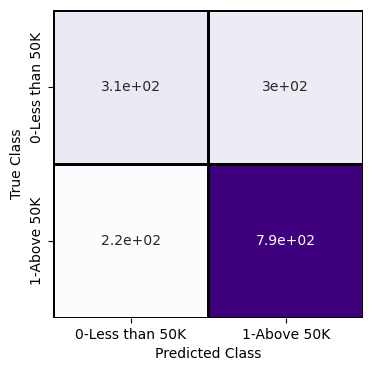

In [25]:
import seaborn as sns
%matplotlib inline
fig, ax= plt.subplots(1,1, figsize=(4,4),dpi=100)

xlabels=['0-Less than 50K','1-Above 50K']
ylabels=['0-Less than 50K','1-Above 50K']

sns.heatmap(conf_matrix1,annot=True, cbar=None, cmap="Purples",xticklabels=xlabels,yticklabels=ylabels,
            linewidths=1,linecolor='black')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')

In [26]:
from sklearn.metrics import classification_report
names=['0-Less than 50K','1-Above 50K']
print(classification_report(y_test, y_pred,target_names=names))
precision,recall,fscore,support = score(y_test,y_pred,average='macro')
NB=fscore
NB

                 precision    recall  f1-score   support

0-Less than 50K       0.58      0.51      0.54       612
    1-Above 50K       0.73      0.78      0.75      1013

       accuracy                           0.68      1625
      macro avg       0.65      0.65      0.65      1625
   weighted avg       0.67      0.68      0.67      1625



0.6482018792427289

In [27]:
#Bagging

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=2)

num_trees = 100
model = BaggingClassifier(max_samples=0.8, n_estimators=num_trees,random_state=8)

model.fit(x_train,y_train)
pred = model.predict(x_test)
print(classification_report(y_test,pred))
precision,recall,fscore,support = score(y_test,pred,average='macro')
BG=fscore
BG

              precision    recall  f1-score   support

           0       0.79      0.72      0.75       724
           1       0.84      0.88      0.86      1226

    accuracy                           0.82      1950
   macro avg       0.81      0.80      0.81      1950
weighted avg       0.82      0.82      0.82      1950



0.8069878018585976

In [28]:
#AdaBoost Classifier

from sklearn.ensemble import AdaBoostClassifier
clf = AdaBoostClassifier(random_state=96,estimator=RandomForestClassifier(random_state=101),
                        n_estimators=100,learning_rate=0.01)
clf.fit(x_train,y_train)
pred = clf.predict(x_test)
print(classification_report(y_test,pred))
report = classification_report(y_test,pred)
precision,recall,fscore,support = score(y_test,pred,average='macro')
ADB=fscore
ADB

C:\Users\ygvin\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.80      0.71      0.75       724
           1       0.84      0.89      0.86      1226

    accuracy                           0.82      1950
   macro avg       0.82      0.80      0.81      1950
weighted avg       0.82      0.82      0.82      1950



0.8069662986852004

In [29]:
# initialize list elements
data = [['Logistic Regression',LR],['KNearest Nighbour',KNN],
        ['Decision Tree',DT],['Random Forest',RD],['Support Vector Machine',SVM],
        ['Navie Bais',NB],['Bagging',BG],['AdaBoosting',ADB]]
# Create the pandas DataFrame with column name is provided explicitly
df = pd.DataFrame(data, columns=['Algorithm Names','Accuracy'])
df

,Algorithm Names,Accuracy
0,Logistic Regression,0.700383
1,KNearest Nighbour,0.644088
2,Decision Tree,0.798352
3,Random Forest,0.819645
4,Support Vector Machine,0.642977
5,Navie Bais,0.648202
6,Bagging,0.806988
7,AdaBoosting,0.806966
